# Feature-Size Analysis via 3D Radial Power Spectrum

Estimate the size of small spatial features in a reconstructed volume using a rigorous
3D Fourier (spectral) method.

**Pipeline**
1. Load volume, subtract the mean (kill the DC term).
2. Apply a separable 3D apodization window (Tukey) to suppress edge/spectral leakage — a sharp
   volume boundary otherwise injects a spurious $q^{-4}$ tail that mimics a Porod signal.
3. Take the 3D FFT (`rfftn`, memory-efficient half-spectrum), square the magnitude.
4. Radially average the power over spherical shells of constant $|q|$ (isotropy assumed).
5. Convert features to real-space length via $d = 2\pi/q$.

**Reading the result**
- A broad spectral peak at $q^*$ ⇒ a dominant center-to-center spacing $d^* = 2\pi/q^*$.
- The high-$q$ slope encodes interface sharpness / surface area (Porod $q^{-4}$ for sharp interfaces).

> Convention used throughout: $q = 2\pi f$, where $f$ is spatial frequency in cycles per unit length.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from scipy import fft as sfft
from scipy.signal.windows import tukey
from scipy.signal import savgol_filter

# ---- Parameters ----------------------------------------------------------
recon_location = "/home/ljh79/TomoMono/reconstructions/APSbeamtime_Oct25/tomopy/tomopyAlgorithmCheck_20260526-104352/cfg_fullres_aligned_20260514-115952_SIRT_CUDA_positivity_20260526-104352.tif"

voxel_size = 30.2         # nm per voxel
length_unit = "nm"

TUKEY_ALPHA = 0.25        # apodization: 0 = boxcar, 1 = full Hann
N_BINS = 600              # radial |q| shells (more bins → finer high-q resolution)
ZERO_PAD_FACTOR = 1       # FFT zero-padding factor. 2 = 2× frequency interpolation, enabling
                          # sub-voxel peak localization. Set to 1 to disable (saves ~ZPF^3 memory).


## 1. Load the volume

volume shape (z, y, x): (400, 1200, 1200) | dtype: float32 | size: 2.30 GB


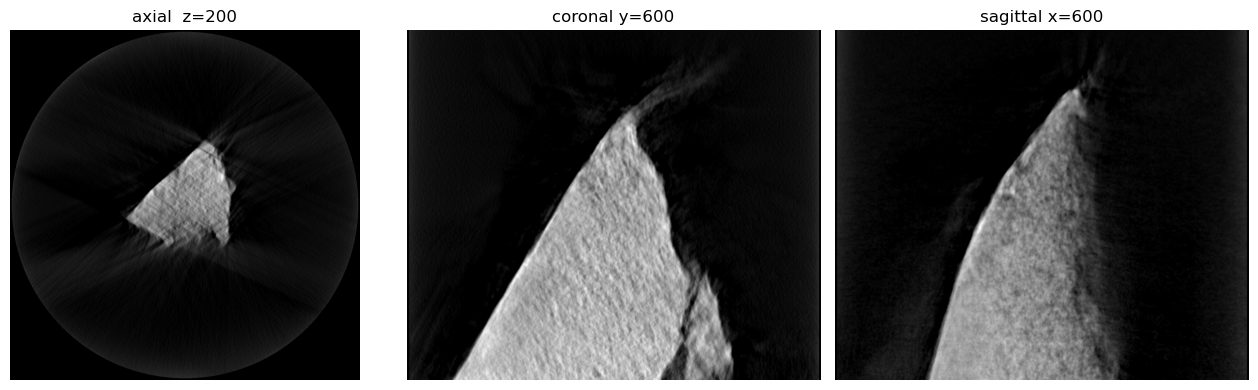

In [2]:
vol = tifffile.imread(recon_location).astype(np.float32, copy=False)
print("volume shape (z, y, x):", vol.shape, "| dtype:", vol.dtype,
      "| size: %.2f GB" % (vol.nbytes / 1e9))
nz, ny, nx = vol.shape

# Orthogonal central slices for a sanity check
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(vol[nz // 2], cmap="gray");      ax[0].set_title(f"axial  z={nz//2}")
ax[1].imshow(vol[:, ny // 2], cmap="gray", aspect="auto"); ax[1].set_title(f"coronal y={ny//2}")
ax[2].imshow(vol[:, :, nx // 2], cmap="gray", aspect="auto"); ax[2].set_title(f"sagittal x={nx//2}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()


## 2. Mean subtraction + 3D radial apodization window

A separable (outer-product) Tukey window creates a *cuboidal* passband that over-attenuates
diagonal directions relative to the axes, biasing the radial average at high $q$.

We replace it with a **radial Tukey window**: the taper is a function of $r/R_\text{max}$ where
$r = \sqrt{x^2+y^2+z^2}$ (voxel coords, origin at volume center) and
$R_\text{max} = \min(N_z, N_y, N_x)/2$ is the inscribed-sphere radius. This gives
*uniform apodization in every direction*. Voxels beyond the inscribed sphere (the corners of
the rectangular volume) are zeroed, which also removes their contribution from the radial average.

The window is applied slice-by-slice to avoid materializing a full 3D weight array.

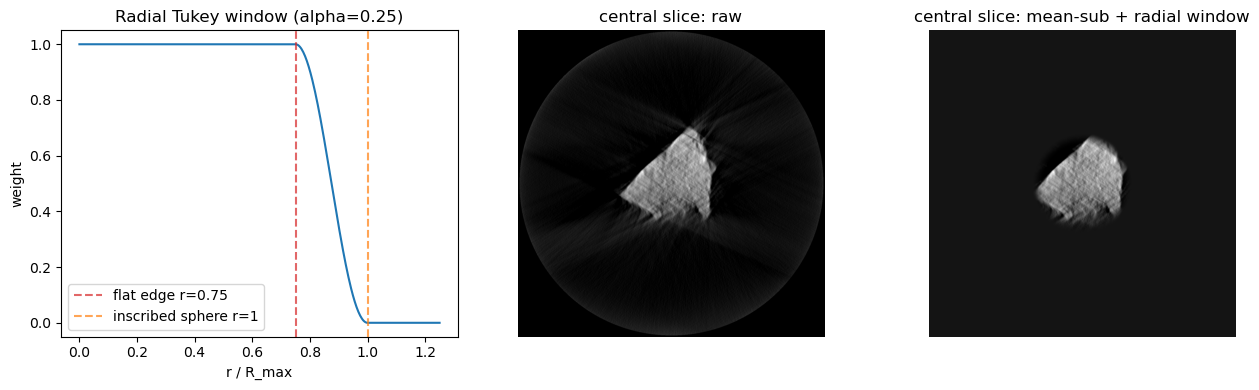

In [3]:
raw_slice = vol[nz // 2].copy()
vol -= vol.mean()  # remove DC

# ── Radial Tukey window ────────────────────────────────────────────────────
# r normalized: r=0 at center, r=1 at the inscribed sphere surface.
# Taper: w=1 for r ≤ (1−α), cosine ramp to 0 at r=1, w=0 for r>1 (corners).
R_max = min(nz, ny, nx) / 2.0
zn = (np.arange(nz) - (nz - 1) / 2.0) / R_max
yn = (np.arange(ny) - (ny - 1) / 2.0) / R_max
xn = (np.arange(nx) - (nx - 1) / 2.0) / R_max
r_inner = 1.0 - TUKEY_ALPHA  # normalized radius where taper begins

for iz, z in enumerate(zn):
    r2d = np.sqrt(z**2 + yn[:, None]**2 + xn[None, :]**2).astype(np.float32)
    w2d = np.where(r2d <= r_inner, 1.0,
          np.where(r2d <= 1.0,
                   0.5 * (1.0 + np.cos(np.pi * (r2d - r_inner) / TUKEY_ALPHA)),
                   0.0)).astype(np.float32)
    vol[iz] *= w2d

# Radial profile for visualization
r_prof = np.linspace(0, 1.25, 400)
w_prof = np.where(r_prof <= r_inner, 1.0,
         np.where(r_prof <= 1.0,
                  0.5 * (1.0 + np.cos(np.pi * (r_prof - r_inner) / TUKEY_ALPHA)),
                  0.0))

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(r_prof, w_prof)
ax[0].axvline(r_inner, color="C3", ls="--", alpha=0.7, label=f"flat edge r={r_inner:.2f}")
ax[0].axvline(1.0,     color="C1", ls="--", alpha=0.7, label="inscribed sphere r=1")
ax[0].set_title(f"Radial Tukey window (alpha={TUKEY_ALPHA})")
ax[0].set_xlabel("r / R_max"); ax[0].set_ylabel("weight"); ax[0].legend()
ax[1].imshow(raw_slice, cmap="gray"); ax[1].set_title("central slice: raw"); ax[1].axis("off")
ax[2].imshow(vol[nz // 2], cmap="gray")
ax[2].set_title("central slice: mean-sub + radial window"); ax[2].axis("off")
plt.tight_layout(); plt.show()
del raw_slice


## 3. 3D FFT and power spectrum

`rfftn` exploits the real input to return only the non-redundant half-spectrum
(last axis length `nxp//2 + 1`), roughly halving memory and time versus a full complex FFT.
`overwrite_x=True` lets SciPy reuse the windowed input buffer, and `workers=-1` uses all cores.

Zero-padding to `(nzp, nyp, nxp) = ZERO_PAD_FACTOR × (nz, ny, nx)` **interpolates** the
frequency grid by the same factor. It does **not** extend the bandwidth beyond Nyquist
(0.5 cycles/voxel = 2-voxel features remain the hard physical limit), but it gives
sub-voxel precision in locating spectral peaks — critical for sizing filaments in the
5-voxel or smaller regime.

half-spectrum power shape: (400, 1200, 601) | 1.15 GB


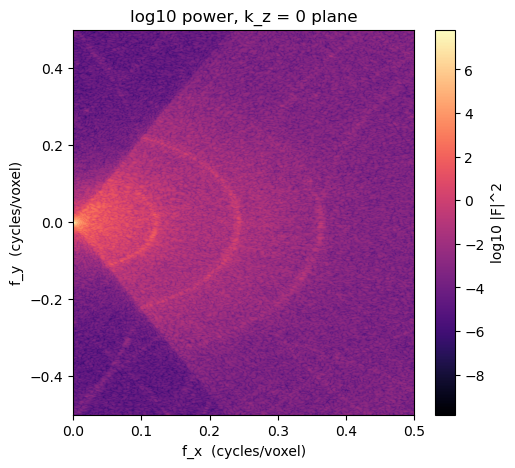

In [4]:
nzp = nz * ZERO_PAD_FACTOR
nyp = ny * ZERO_PAD_FACTOR
nxp = nx * ZERO_PAD_FACTOR
if ZERO_PAD_FACTOR > 1:
    peak_gb = nzp * nyp * (nxp // 2 + 1) * 8 / 1e9
    print(f"Zero-padding ({nz},{ny},{nx}) → ({nzp},{nyp},{nxp}); "
          f"peak FFT memory ≈ {peak_gb:.1f} GB (complex64)")

F = sfft.rfftn(vol, s=(nzp, nyp, nxp), overwrite_x=True, workers=-1)
del vol
power = (F.real**2 + F.imag**2).astype(np.float32)
del F
print("half-spectrum power shape:", power.shape, "| %.2f GB" % (power.nbytes / 1e9))

# log-power slice through kz=0 plane (fftshift only the two full axes for display)
disp = np.log10(power[0] + 1e-12)
disp = np.fft.fftshift(disp, axes=0)
plt.figure(figsize=(5.5, 5))
plt.imshow(disp, cmap="magma", aspect="auto", extent=[0, 0.5, -0.5, 0.5])
plt.xlabel("f_x  (cycles/voxel)"); plt.ylabel("f_y  (cycles/voxel)")
plt.title("log10 power, k_z = 0 plane"); plt.colorbar(label="log10 |F|^2"); plt.show()


## 4. Radial average over spherical shells

For each spectral sample we compute the physical wavenumber
$q = 2\pi\sqrt{f_z^2+f_y^2+f_x^2}\,/\,\Delta$ (with $\Delta$ = `voxel_size`) and bin the power into
shells of constant $|q|$. Because `rfftn` dropped the negative-$f_x$ half, every sample with
$0 < f_x < f_{\text{Nyquist}}$ represents two conjugate points, so we weight it by 2.

The radial Tukey window has already zeroed the volume corners, so those voxels contribute zero
power — no additional corner-masking is needed in the radial average.

In [5]:
# Frequency axes in cycles/voxel — use padded sizes so bin spacing is ZPF× finer,
# but Nyquist (0.5 cycles/voxel) is unchanged (padding doesn't extend bandwidth).
fz = np.fft.fftfreq(nzp).astype(np.float32)
fy = np.fft.fftfreq(nyp).astype(np.float32)
fx = np.fft.rfftfreq(nxp).astype(np.float32)   # 0 .. 0.5

fmag = np.sqrt(fz[:, None, None]**2 + fy[None, :, None]**2 + fx[None, None, :]**2)

# Hermitian weight: count conjugate partner for interior kx columns
wkx = np.full(nxp // 2 + 1, 2.0, dtype=np.float32)
wkx[0] = 1.0
if nxp % 2 == 0:
    wkx[-1] = 1.0
weight = np.broadcast_to(wkx[None, None, :], power.shape)

f_ny = 0.5
bin_idx = np.clip((fmag.ravel() / f_ny * N_BINS).astype(np.int64), 0, N_BINS - 1)
del fmag

wsum = np.bincount(bin_idx, weights=(power.ravel() * weight.ravel()), minlength=N_BINS)
wcnt = np.bincount(bin_idx, weights=weight.ravel(), minlength=N_BINS)
del power, weight, bin_idx

psd = wsum / np.maximum(wcnt, 1e-12)
f_centers = (np.arange(N_BINS) + 0.5) / N_BINS * f_ny      # cycles/voxel
q = 2 * np.pi * f_centers / voxel_size                      # angular wavenumber (1/length)
valid = wcnt > 0

d_nyquist = 2.0 * voxel_size
print(f"non-empty shells: {valid.sum()} / {N_BINS}")
print(f"Frequency resolution: Δf = {f_ny/N_BINS:.5f} cycles/voxel per bin  "
      f"({f_ny/N_BINS*voxel_size:.4f} cycles/{length_unit})")
print(f"Hard Nyquist limit:   d_min = 2 voxels = {d_nyquist:.1f} {length_unit}  "
      f"(features must be ≥ {d_nyquist:.1f} {length_unit} to be resolvable)")


non-empty shells: 600 / 600
Frequency resolution: Δf = 0.00083 cycles/voxel per bin  (0.0252 cycles/nm)
Hard Nyquist limit:   d_min = 2 voxels = 60.4 nm  (features must be ≥ 60.4 nm to be resolvable)


## 5. Radial PSD and feature-size readout

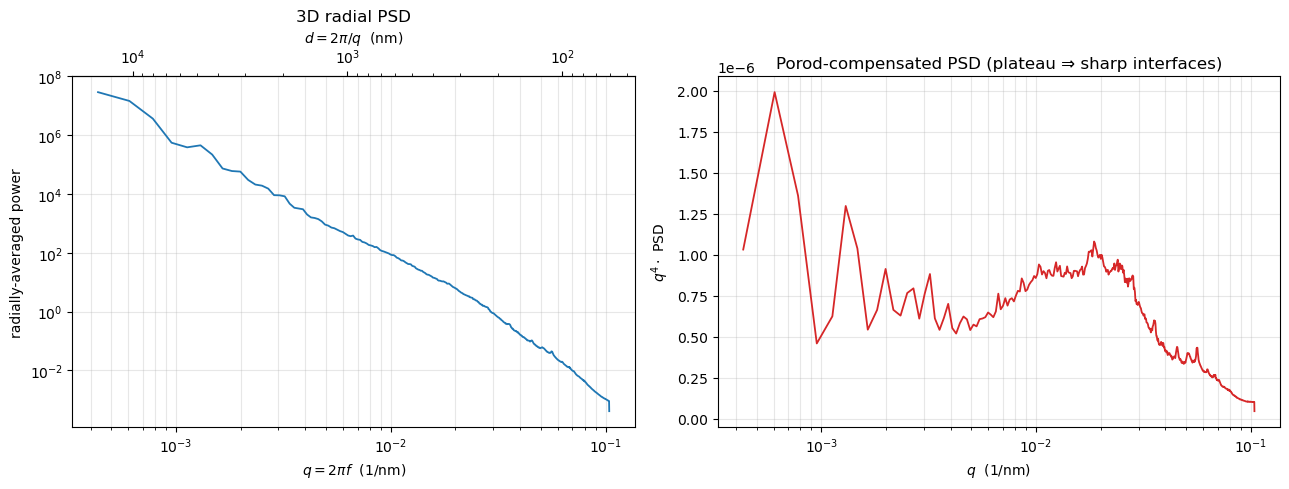

In [6]:
# Drop the first couple of bins (residual DC / poorly sampled lowest shells)
m = valid.copy(); m[:2] = False
qm, pm = q[m], psd[m]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (a) log-log PSD vs q, with a real-space-length top axis
ax[0].loglog(qm, pm, lw=1.3)
ax[0].set_xlabel(r"$q = 2\pi f$  (1/%s)" % length_unit)
ax[0].set_ylabel("radially-averaged power")
ax[0].set_title("3D radial PSD")
ax[0].grid(True, which="both", alpha=0.3)
secax = ax[0].secondary_xaxis("top", functions=(lambda x: 2*np.pi/np.where(x==0, np.nan, x),
                                                lambda d: 2*np.pi/np.where(d==0, np.nan, d)))
secax.set_xlabel(r"$d = 2\pi/q$  (%s)" % length_unit)

# (b) Porod-compensated PSD: q^4 * PSD should plateau where interfaces are sharp
ax[1].semilogx(qm, pm * qm**4, lw=1.3, color="C3")
ax[1].set_xlabel(r"$q$  (1/%s)" % length_unit)
ax[1].set_ylabel(r"$q^4 \cdot$ PSD")
ax[1].set_title("Porod-compensated PSD (plateau ⇒ sharp interfaces)")
ax[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


### Dominant spacing $q^*$ and Porod (high-$q$) slope

We smooth the PSD lightly, find the strongest interior peak in $q^2\cdot\text{PSD}$ (the
shell-volume-compensated spectrum, which makes a genuine length-scale peak stand out against the
monotonic background), and report $d^* = 2\pi/q^*$. The Porod slope is a straight-line fit to
$\log\text{PSD}$ vs $\log q$ over the high-$q$ decade.

Dominant feature spacing:  q* = 0.051 1/nm  ->  d* = 123.2 nm  (4.08 voxels)
  (sub-bin parabolic offset: -0.347 bins)
  Small feature detected: 4.08 voxels (≤ 5 voxel regime).
High-q power-law slope: -6.88   (fit over q=[0.0765, 0.0935] 1/nm; Porod = -4.0 for ideal sharp interfaces)


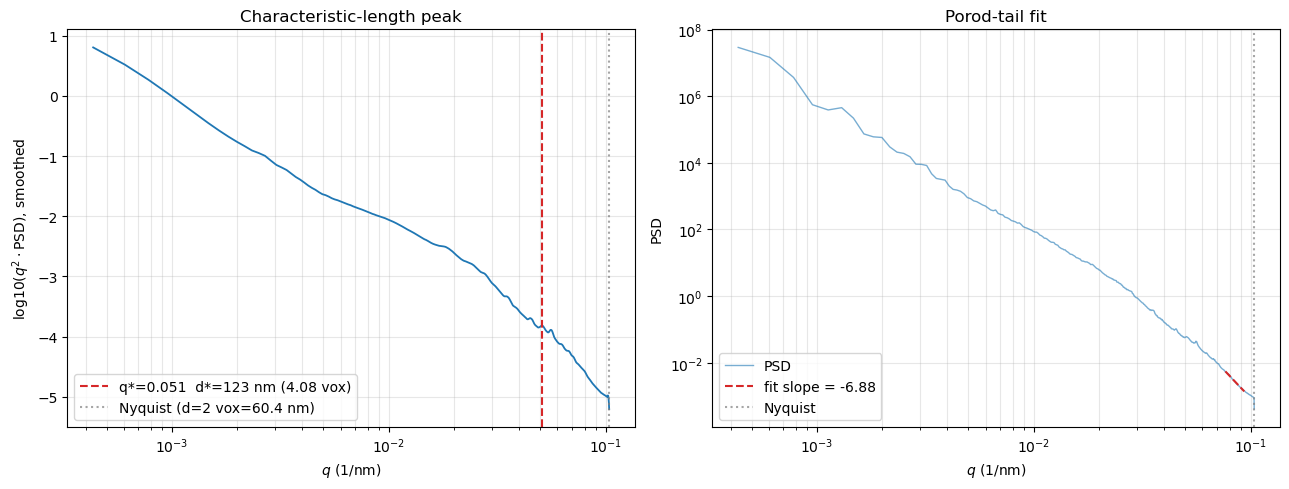

In [7]:
from scipy.signal import find_peaks

comp = pm * qm**2
log_comp = np.log10(comp)
sm = savgol_filter(log_comp, min(21, len(log_comp) // 2 * 2 - 1), 3)

peaks, _ = find_peaks(sm, prominence=0.03)
q_nyquist = np.pi / voxel_size   # angular wavenumber at Nyquist

if len(peaks):
    p = peaks[np.argmax(sm[peaks])]
    # Quadratic (parabolic) interpolation: shifts the detected bin by a sub-bin offset
    # so that the reported q* has precision finer than a single frequency bin.
    if 0 < p < len(sm) - 1:
        a, b, c = sm[p-1], sm[p], sm[p+1]
        delta = 0.5 * (a - c) / (a - 2*b + c + 1e-30)
    else:
        delta = 0.0
    q_star = float(np.interp(p + delta, np.arange(len(qm)), qm))
    d_star = 2 * np.pi / q_star
    d_star_vox = d_star / voxel_size
    print(f"Dominant feature spacing:  q* = {q_star:.4g} 1/{length_unit}"
          f"  ->  d* = {d_star:.4g} {length_unit}  ({d_star_vox:.2f} voxels)")
    print(f"  (sub-bin parabolic offset: {delta:+.3f} bins)")
    if d_star_vox < 2.0:
        print("  WARNING: peak below 2-voxel Nyquist limit — likely a spectral artifact.")
    elif d_star_vox <= 5.0:
        print(f"  Small feature detected: {d_star_vox:.2f} voxels (≤ 5 voxel regime).")
else:
    q_star = d_star = None
    print("No clear interior peak — spectrum is monotonic (no single dominant spacing).")

q_hi = 0.9 * qm.max()
q_lo = min(q_star * 1.5, q_hi) if q_star else qm[len(qm) // 3]
fit_m = (qm >= q_lo) & (qm <= q_hi)
if fit_m.sum() < 5:
    q_lo = qm.min() + 0.6 * (qm.max() - qm.min())
    fit_m = (qm >= q_lo) & (qm <= q_hi)
slope, intercept = np.polyfit(np.log10(qm[fit_m]), np.log10(pm[fit_m]), 1)
print(f"High-q power-law slope: {slope:.2f}   (fit over q=[{q_lo:.3g}, {q_hi:.3g}] 1/{length_unit};"
      f" Porod = -4.0 for ideal sharp interfaces)")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].semilogx(qm, sm, lw=1.3)
if q_star:
    ax[0].axvline(q_star, color="C3", ls="--",
                  label=f"q*={q_star:.3g}  d*={d_star:.3g} {length_unit} ({d_star_vox:.2f} vox)")
ax[0].axvline(q_nyquist, color="gray", ls=":", alpha=0.7,
              label=f"Nyquist (d=2 vox={2*voxel_size:.1f} {length_unit})")
ax[0].set_xlabel(r"$q$ (1/%s)" % length_unit); ax[0].set_ylabel(r"log10($q^2\cdot$PSD), smoothed")
ax[0].set_title("Characteristic-length peak"); ax[0].legend(); ax[0].grid(True, which="both", alpha=0.3)

ax[1].loglog(qm, pm, lw=1.0, alpha=0.6, label="PSD")
ax[1].loglog(qm[fit_m], 10**intercept * qm[fit_m]**slope, "C3--",
             label=f"fit slope = {slope:.2f}")
ax[1].axvline(q_nyquist, color="gray", ls=":", alpha=0.7, label="Nyquist")
ax[1].set_xlabel(r"$q$ (1/%s)" % length_unit); ax[1].set_ylabel("PSD")
ax[1].set_title("Porod-tail fit"); ax[1].legend(); ax[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


### PSD as a function of real-space length $d$

The same radial PSD, re-plotted against length $d = 2\pi/q$ instead of wavenumber $q$. Large
features sit on the right, fine features on the left. The shell-volume-compensated $q^2\cdot$PSD
makes the characteristic length $d^*$ stand out as a peak.

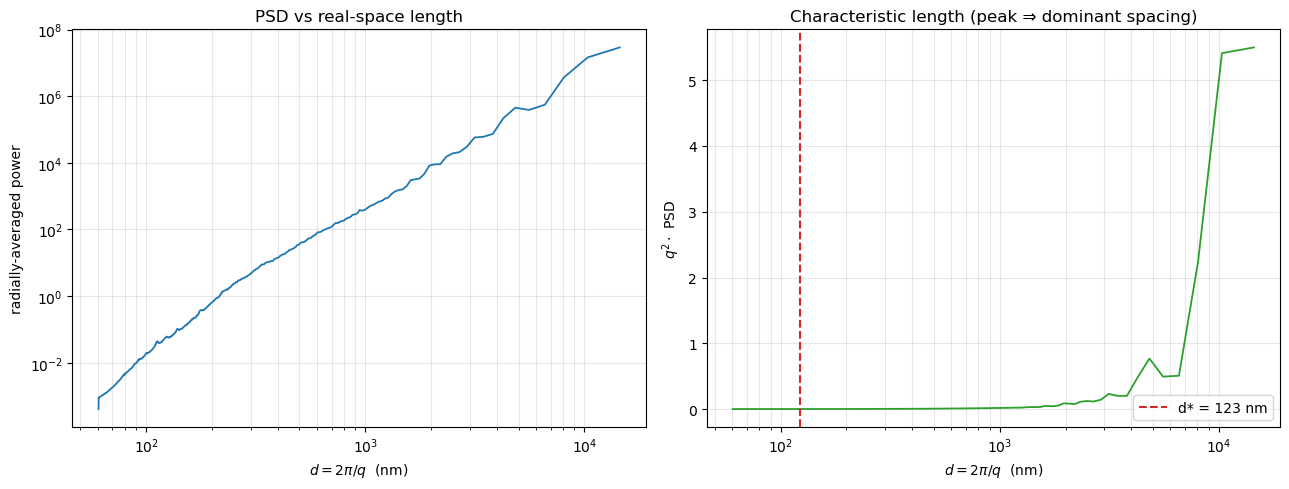

In [8]:
d = 2 * np.pi / qm                                 # real-space length per shell (length_unit)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (a) PSD vs distance
ax[0].loglog(d, pm, lw=1.3)
ax[0].set_xlabel(r"$d = 2\pi/q$  (%s)" % length_unit)
ax[0].set_ylabel("radially-averaged power")
ax[0].set_title("PSD vs real-space length")
ax[0].grid(True, which="both", alpha=0.3)

# (b) shell-volume-compensated PSD vs distance, with d* marked
ax[1].semilogx(d, pm * qm**2, lw=1.3, color="C2")
if d_star:
    ax[1].axvline(d_star, color="C3", ls="--", label=f"d* = {d_star:.3g} {length_unit}")
    ax[1].legend()
ax[1].set_xlabel(r"$d = 2\pi/q$  (%s)" % length_unit)
ax[1].set_ylabel(r"$q^2 \cdot$ PSD")
ax[1].set_title("Characteristic length (peak ⇒ dominant spacing)")
ax[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


## Interpretation

- **`d*`** is the dominant center-to-center spacing of features, in nm (voxel pitch = 30.2 nm).
  If no peak was found, the structure has no single preferred length scale over the measured band.
- **High-$q$ slope** near **$-4$** ⇒ sharp, well-defined interfaces (Porod regime; the $q^4\cdot$PSD
  plateau confirms this). A shallower slope ($-3$ to $-4$) suggests rough/diffuse interfaces or
  fractal surface scaling.
- **Sanity checks:** the result must sit between the largest resolvable scale
  ($d \le$ volume extent) and the voxel limit ($d \ge 2$ voxels at Nyquist). Re-running with a
  stronger window (`TUKEY_ALPHA` → 0.5) should leave the peak in place but flatten any spurious
  boundary-induced $q^{-4}$ tail — a good way to confirm the Porod slope is physical, not an
  apodization artifact.
- **Anisotropy:** this averages over full spherical shells (assumes isotropy). If features have a
  preferred axis (e.g. filaments), replace the spherical binning with conical/sector binning around
  that axis to separate along- vs across-filament length scales.
